In [1]:
import tensorflow as tf
from tensorflow import keras
#from keras.layers import Conv2D, Conv2DTranspose, MaxPooling2D, Flatten, Dense, Lambda, Reshape

from keras import ops
from keras import layers

from keras import Model, Input
from keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
import os 
import sys

sys.path.append(os.path.abspath('..'))
from proyecto1_deep_learning.data_loader import load_data_3



2026-02-24 22:27:08.990984: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-24 22:27:09.058717: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-24 22:27:10.727903: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 1886637979372774118
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 3758096384
locality {
  bus_id: 1
  links {
  }
}
incarnation: 16438203334291524944
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6"
xla_global_id: 416903419
]
2.20.0
Num GPUs Available:  1


I0000 00:00:1771993632.516936   18665 gpu_device.cc:2020] Created device /device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [3]:
##why the helly does this not work?
x_train, x_test = load_data_3()

image_shape = x_train.shape[1:]
num_channels = image_shape[2]
print(f"Image shape: {image_shape}")

Image shape: (128, 128, 3)


In [4]:
x_train.shape, x_test.shape

((168, 128, 128, 3), (43, 128, 128, 3))

In [5]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

print(f'x_train min: {x_train.min()}, max: {x_train.max()}')
print(f'x_test min: {x_test.min()}, max: {x_test.max()}')

x_train min: 0.0, max: 1.0
x_test min: 0.0, max: 1.0


In [6]:
x_train.shape, x_test.shape

((168, 128, 128, 3), (43, 128, 128, 3))

## variational autencoder

to my understanding, generally is:
* we have the original or master latent space whcih we are trying to achieve.
* usually we basically translate neurons language into  a latent space by losing information, and making the language it speaks to say more complex, or so that the general directions which it aims to have mroe meaning. it also means that because each neron has more menaing and is more complex understanding how each position or movement through 3d space makes no sesnse because it chose how to organize itself.
* so in this particalr scenario we give it a language of how to translate into latent space.
* we are basically discifering ho to translate languages or information. so to translate information we first translate the ideal latent space representation or what the model should look like if done like a classic AE, and then we translate as to how taht would look in a noraml distribution. we cast it to a normal distrivution. if we have point a, then its probably in point b, and so on. thus showing spacial relevance.
* and from this normal distribution we can recreate the image.


## first lets do on elike this link:
https://keras.io/examples/generative/vae/ 

In [7]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon


In [8]:
latent_dim = 2
image_size_x = 128
image_size_y = 128

encoder_inputs = keras.Input(shape=(image_size_x, image_size_y, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(256, 3, activation="relu", strides=2, padding="same")(x)

shape_before_flattening = x.shape[1:]  

x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x) #might have to increase this but this shi is gonna be massive ai recommended 128
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()


I0000 00:00:1771993632.876893   18665 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     73,856 │ conv2d_1[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16384)     │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │    262,160 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 650,644 (2.48 MB)

 Trainable params: 650,644 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
latent_inputs = keras.Input(shape=(latent_dim,))


x = layers.Dense(np.prod(shape_before_flattening), activation="relu")(latent_inputs)
x = layers.Reshape(shape_before_flattening)(x)


x = layers.Conv2DTranspose(256, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16384)          │        49,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 128, 128, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027,395 (3.92 MB)

 Trainable params: 1,027,395 (3.92 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # MSE loss (no automatic reduction)
            reconstruction_loss = ops.mean(
                ops.sum(
                    ops.square(data - reconstruction),
                    axis=(1, 2, 3),
                )
            )

            # KL divergence
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [11]:
motorcycle_brum_brum = np.concatenate([x_train, x_test], axis=0)


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
vae.fit(motorcycle_brum_brum, epochs=30)


Epoch 1/30


2026-02-24 22:27:16.459089: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fa4ac013f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-24 22:27:16.459135: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-02-24 22:27:16.634850: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-24 22:27:17.442380: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-24 22:27:28.684666: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng25{k2=0,k3=0} for conv (f32[32,64,33,33]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,16,16]{3,2,1,0}, f32[128,64,3,3]{3,2,1,0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput

1/7 ━━━━━━━━━━━━━━━━━━━━ 1:23 14s/step - kl_loss: 0.0151 - loss: 9438.8594 - reconstruction_loss: 9438.8447

I0000 00:00:1771993647.522191   18709 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - kl_loss: 12.8843 - loss: 9404.4537 - reconstruction_loss: 9391.5699

2026-02-24 22:27:28.895667: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1377', 4 bytes spill stores, 4 bytes spill loads

2026-02-24 22:27:29.193159: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1377', 4 bytes spill stores, 4 bytes spill loads

2026-02-24 22:27:29.691458: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_609', 4 bytes spill stores, 4 bytes spill loads

2026-02-24 22:27:29.934670: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_609', 4 bytes spill stores, 4 bytes spill loads



7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - kl_loss: 188.5760 - loss: 8592.1406 - reconstruction_loss: 8403.5654
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - kl_loss: 25.4152 - loss: 4556.4941 - reconstruction_loss: 4531.0796
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - kl_loss: 0.0550 - loss: 2935.9382 - reconstruction_loss: 2935.8831
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - kl_loss: 2.8693e-05 - loss: 2398.7219 - reconstruction_loss: 2398.7219
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - kl_loss: 7.8555e-05 - loss: 2225.8547 - reconstruction_loss: 2225.8547
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - kl_loss: 1.2790e-04 - loss: 2189.7156 - reconstruction_loss: 2189.7153
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - kl_loss: 1.5995e-04 - loss: 2179.7620 - reconstruction_loss: 2179.7617
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - kl_loss: 1.7231e-04 - loss: 2154.0740 - reconstruction_loss: 2154.0737
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 983ms/

2026-02-24 22:27:48.719869: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng20{k2=2,k4=1,k5=0,k6=0,k7=0,k19=0} for conv (f32[5,256,8,8]{3,2,1,0}, u8[0]{0}) custom-call(f32[5,128,17,17]{3,2,1,0}, f32[256,128,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-02-24 22:27:48.720037: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 5.738438613s
Trying algorithm eng20{k2=2,k4=1,k5=0,k6=0,k7=0,k19=0} for conv (f32[5,256,8,8]{3,2,1,0}, u8[0]{0}) custom-call(f32[5,128,17,17]{3,2,1,0}, f32[256,128,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi0

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


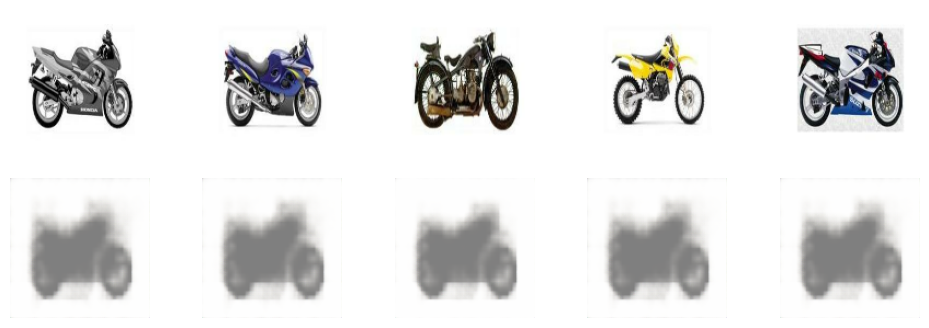

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def show_reconstructions(model, data, n=5):
    z_mean, z_log_var, z = model.encoder.predict(data[:n])
    reconstructions = model.decoder.predict(z)

    plt.figure(figsize=(12, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i])
        plt.axis("off")

        # Reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructions[i])
        plt.axis("off")

    plt.show()

show_reconstructions(vae, motorcycle_brum_brum)